# 01 - Análise Exploratória (EDA)

**O que este notebook faz:** carrega o dataset bruto, verifica a qualidade dos dados (nulos, duplicadas), explora a distribuição do preço de venda e como ela varia por produto/região/estado/bandeira, e faz uma primeira olhada visual em possíveis outliers — tudo sem treinar nenhum modelo. É o passo 1 do fluxo EDA -> baseline -> modelos -> tuning -> avaliação.

**Dataset:** Série Histórica de Preços de Combustíveis - ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis)

Levantamento mensal de preços de venda de gasolina, gasolina aditivada e etanol por posto revendedor, coletado pela ANP em todo o Brasil. Fonte pública: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis (referência: dezembro/2025).

**Por que este dataset serve para detecção de anomalias?** Não existe rótulo de fraude/erro, mas o problema é naturalmente desbalanceado no sentido que interessa: a grande maioria dos postos vende pelo preço de mercado da sua região/produto, e só uma pequena fração tem preços muito fora do padrão (erro de digitação no boletim, posto muito acima ou abaixo da concorrência). É exatamente o cenário de IsolationForest, LocalOutlierFactor e OneClassSVM: aprender o que é 'normal' e apontar os poucos pontos que destoam.

**Este notebook é SOMENTE EDA.** Não há split treino/teste nem modelagem aqui — isso começa no notebook `02_preprocessing_baseline`.

## 1. Imports

In [1]:
import sys
sys.path.append('..')  # permite importar o pacote src/ a partir de notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # testes estatísticos (normalidade, Kruskal-Wallis) e MAD robusto

from src.data import carregar_dados  # função reutilizável de carga/limpeza

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = '../data/precos_combustiveis_anp_2025-12.csv'

df = carregar_dados(CAMINHO_DADOS)
print('Linhas x Colunas:', df.shape)
df.head()

Linhas x Colunas: (52336, 10)


,regiao,estado,municipio,revenda,cnpj_revenda,produto,data_coleta,valor_venda,unidade_medida,bandeira
0,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,GASOLINA,2025-12-01,6.14,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,GASOLINA ADITIVADA,2025-12-01,6.14,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,AUTO POSTO M M GARROTE LTDA,08.738.994/0001-50,ETANOL,2025-12-01,4.79,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,GASOLINA,2025-12-01,6.19,R$ / litro,BRANCA
4,NE,AL,ARAPIRACA,AUTO POSTO MASSARANDUBA LTDA,07.248.398/0001-29,GASOLINA ADITIVADA,2025-12-01,6.19,R$ / litro,BRANCA


**Resultado:** 52.336 registros e 10 colunas. `carregar_dados` já descarta as colunas de endereço (rua, número, complemento, bairro, cep) e a coluna `Valor de Compra` (100% vazia no arquivo original), que não ajudam a explicar preço anômalo.

## 3. Visão geral e qualidade dos dados

Cada linha é uma coleta de preço: um produto (gasolina, gasolina aditivada ou etanol) vendido por um posto, em uma data específica.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52336 entries, 0 to 52335
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   regiao          52336 non-null  str           
 1   estado          52336 non-null  str           
 2   municipio       52336 non-null  str           
 3   revenda         52336 non-null  str           
 4   cnpj_revenda    52336 non-null  str           
 5   produto         52336 non-null  str           
 6   data_coleta     52336 non-null  datetime64[us]
 7   valor_venda     52336 non-null  float64       
 8   unidade_medida  52336 non-null  str           
 9   bandeira        52336 non-null  str           
dtypes: datetime64[us](1), float64(1), str(8)
memory usage: 4.0 MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
regiao,52336,5,SE,25722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado,52336,27,SP,15534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio,52336,397,SAO PAULO,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenda,52336,5103,SIM REDE DE POSTOS LTDA,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cnpj_revenda,52336,5737,08.505.094/0001-62,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto,52336,3,GASOLINA,19948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_coleta,52336,NaN,NaN,NaN,2025-12-15 14:40:57.597065,2025-12-01 00:00:00,2025-12-08 00:00:00,2025-12-16 00:00:00,2025-12-23 00:00:00,2025-12-31 00:00:00,NaN
valor_venda,52336.0,NaN,NaN,NaN,5.728101,3.49,4.79,5.99,6.39,9.59,0.908264
unidade_medida,52336,1,R$ / litro,52336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bandeira,52336,45,BRANCA,17003,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

Series([], dtype: int64)

In [6]:
# Linhas duplicadas (mesmo posto + produto + data + preço)
print('Duplicadas:', df.duplicated().sum())

Duplicadas: 0


**Resultado:** nenhuma coluna com valor nulo e nenhuma linha duplicada. Os dados já chegam limpos o suficiente para seguir direto para a análise — não há necessidade de imputação ou deduplicação antes do split treino/teste.

## 4. Cobertura geográfica e temporal

Quantos estados/regiões estão representados e qual o período coberto — importante para saber se faz sentido comparar preços entre estados.

In [7]:
print('Estados:', df['estado'].nunique())
print('Regiões:', sorted(df['regiao'].unique()))
print('Período:', df['data_coleta'].min().date(), 'a', df['data_coleta'].max().date())
print('Bandeiras (marcas):', df['bandeira'].nunique())

Estados: 27
Regiões: ['CO', 'N', 'NE', 'S', 'SE']
Período: 2025-12-01 a 2025-12-31
Bandeiras (marcas): 45


In [8]:
df['produto'].value_counts().to_frame('registros')

,registros
produto,
GASOLINA,19948
ETANOL,16747
GASOLINA ADITIVADA,15641


**Resultado:** cobertura nacional completa — os 27 estados e as 5 regiões aparecem na base, com coleta ao longo de todo dezembro/2025 e 45 bandeiras distintas. Os 3 produtos também estão bem distribuídos (38% gasolina, 32% etanol, 30% gasolina aditivada), o que dá uma base sólida para estratificar o split treino/teste por `produto` no notebook 02 e para calcular medianas de referência confiáveis por estado/produto.

## 5. Distribuição do preço de venda

Preço (`valor_venda`) é a única variável numérica de interesse direto — é a partir dela que as futuras features de anomalia serão construídas.

In [9]:
df['valor_venda'].describe()

count    52336.000000
mean         5.728101
std          0.908264
min          3.490000
25%          4.790000
50%          5.990000
75%          6.390000
max          9.590000
Name: valor_venda, dtype: float64

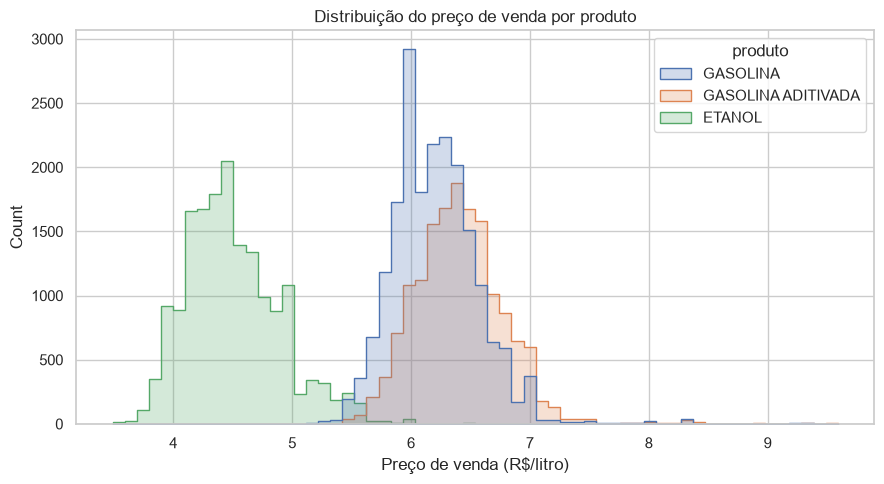

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='valor_venda', hue='produto', bins=60, element='step', ax=ax)
ax.set_title('Distribuição do preço de venda por produto')
ax.set_xlabel('Preço de venda (R$/litro)')
plt.tight_layout()
plt.savefig('../reports/eda_distribuicao_preco_por_produto.png', dpi=120)
plt.show()

**Resultado:** preço varia de R$ 3,49 a R$ 9,59 (média R$ 5,73). O histograma mostra três distribuições bem separadas — etanol forma um agrupamento mais barato e à esquerda, gasolina e gasolina aditivada ficam mais caras e próximas entre si. Ou seja: o mesmo preço absoluto pode ser normal para um produto e anômalo para outro, então qualquer análise de anomalia precisa comparar o preço dentro do próprio produto (e, como veremos a seguir, dentro da própria região).

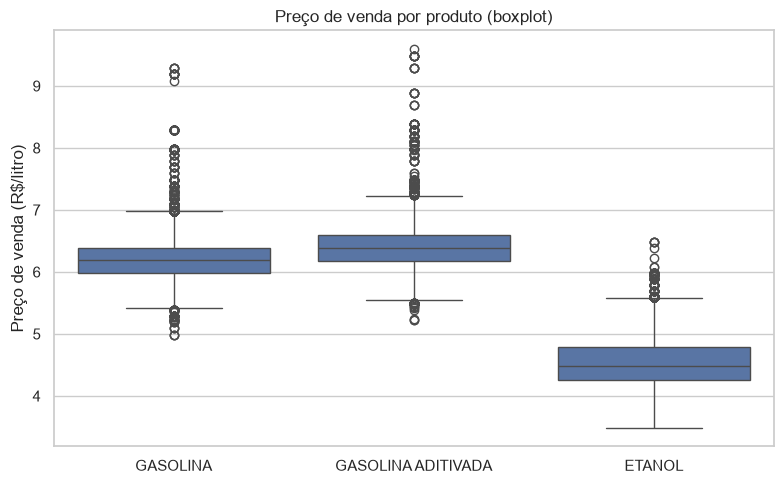

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='produto', y='valor_venda', ax=ax)
ax.set_title('Preço de venda por produto (boxplot)')
ax.set_xlabel('')
ax.set_ylabel('Preço de venda (R$/litro)')
plt.tight_layout()
plt.show()

**Resultado:** o boxplot confirma o etanol como o produto mais barato e com maior espalhamento relativo. Já aparecem pontos fora dos bigodes (outliers univariados) nos três produtos — candidatos naturais a anomalia, que os modelos dos próximos notebooks vão tentar capturar de forma sistemática.

### 5.1 Forma da distribuição: assimetria, curtose e normalidade

O histograma sugere que cada produto tem uma cauda mais longa para a direita (poucos preços bem altos). Para sair do "parece" e ir para o "é", medimos isso formalmente:

- **Assimetria (skewness):** 0 = simétrica; positiva = cauda mais longa à direita (poucos preços muito altos puxando a média para cima); negativa = cauda mais longa à esquerda.
- **Curtose em excesso (excess kurtosis):** 0 = tão "pesada nas caudas" quanto uma normal; positiva (leptocúrtica) = caudas mais pesadas que a normal, ou seja, valores extremos são mais frequentes do que uma distribuição normal preveria — exatamente o que importa para decidir se é seguro tratar `valor_venda` como aproximadamente normal.

Calculamos isso **por produto**, nunca no `valor_venda` agregado dos 3 produtos juntos: como vimos no histograma, misturar 3 distribuições com centros diferentes (etanol vs. gasolina vs. gasolina aditivada) cria uma forma artificial de mistura (multimodal) cuja assimetria/curtose agregada não descreve bem nenhum dos grupos individualmente — um efeito parecido com o paradoxo de Simpson aplicado à forma da distribuição.

In [12]:
forma = df.groupby('produto')['valor_venda'].agg(
    n='count',
    assimetria=lambda x: stats.skew(x),
    curtose_excesso=lambda x: stats.kurtosis(x),  # kurtosis() do scipy já subtrai 3 (excesso)
)
forma

,n,assimetria,curtose_excesso
produto,,,
ETANOL,16747,0.699716,0.539209
GASOLINA,19948,1.187747,5.703161
GASOLINA ADITIVADA,15641,1.114078,5.359939


**Resultado:** os três produtos têm assimetria positiva (ETANOL 0,70; GASOLINA ADITIVADA 1,11; GASOLINA 1,19) — confirma a cauda à direita que já aparecia no histograma: há mais espaço para preços "muito acima" do centro do que "muito abaixo" (faz sentido: preço tem um piso próximo do custo, mas não tem teto). A curtose é onde a diferença fica marcante: ETANOL tem curtose em excesso de apenas 0,54 (próxima de uma normal), enquanto GASOLINA (5,70) e GASOLINA ADITIVADA (5,36) são fortemente leptocúrticas — caudas bem mais pesadas que uma normal preveria. Na prática isso quer dizer que, para gasolina e gasolina aditivada, valores extremos não são raridade estatística tão rara quanto uma normal sugeriria — reforçando que métodos de detecção de anomalia baseados em normalidade (como o z-score clássico da seção 8) tendem a subestimar o problema justamente nesses dois produtos.

**Teste formal de normalidade.** Assimetria e curtose já são fortes indícios contra a normalidade, mas o teste de D'Agostino-Pearson (`scipy.stats.normaltest`) combina as duas em uma única estatística de hipótese: H0 = "a amostra vem de uma distribuição normal". Preferimos este teste ao clássico Shapiro-Wilk porque o Shapiro perde confiabilidade acima de ~5.000 amostras — aqui os grupos têm 15 a 20 mil linhas.

In [13]:
normalidade = df.groupby('produto')['valor_venda'].apply(
    lambda x: pd.Series(stats.normaltest(x), index=['estatistica', 'p_valor'])
).unstack()
normalidade

,estatistica,p_valor
produto,,
ETANOL,1252.109830,1.281755e-272
GASOLINA,5452.157828,0.000000e+00
GASOLINA ADITIVADA,3984.669220,0.000000e+00


**Resultado:** para os três produtos o p-valor é essencialmente zero (ETANOL ≈1,3×10⁻²⁷²; GASOLINA e GASOLINA ADITIVADA abaixo da precisão de ponto flutuante) — rejeitamos H0 com folga em qualquer nível de significância usual (0,05, 0,01, 0,001...). `valor_venda` **não** é normal em nenhum dos três grupos, mesmo dentro de cada produto isoladamente.

Essa conclusão tem consequências práticas diretas para o resto da análise:
- Justifica preferir **mediana e MAD** (estatísticas robustas, não assumem normalidade) a **média e desvio-padrão** para definir o que é "preço típico" — e é exatamente por isso que `ReferenciaPrecos` (notebook 02) usa a mediana, não a média, como referência.
- Justifica usar **Kruskal-Wallis** (não-paramétrico) em vez de ANOVA clássica para comparar preços entre regiões/estados na próxima seção, já que a ANOVA assume normalidade dos resíduos.

## 6. Preço por região

Combustível no Brasil varia bastante por região (frete, tributação estadual). Ver essa variação ajuda a decidir se a feature de anomalia deve comparar o preço contra a média nacional ou contra a média regional/estadual (decisão tomada no notebook 02).

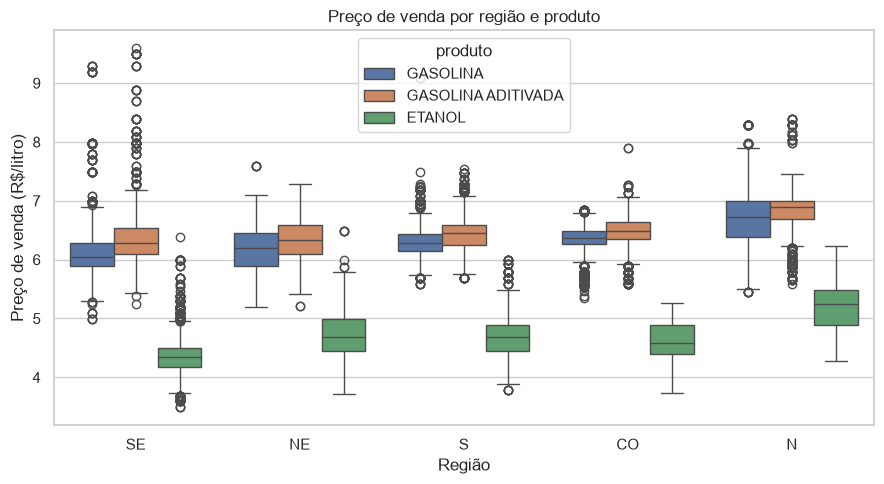

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem_regiao = df.groupby('regiao')['valor_venda'].median().sort_values().index
sns.boxplot(data=df, x='regiao', y='valor_venda', order=ordem_regiao, hue='produto', ax=ax)
ax.set_title('Preço de venda por região e produto')
ax.set_xlabel('Região')
ax.set_ylabel('Preço de venda (R$/litro)')
plt.tight_layout()
plt.savefig('../reports/eda_boxplot_preco_por_regiao.png', dpi=120)
plt.show()

In [15]:
mediana_estado = (
    df.groupby(['estado', 'produto'])['valor_venda']
    .median()
    .unstack('produto')
    .sort_values('GASOLINA')
)
mediana_estado

produto,ETANOL,GASOLINA,GASOLINA ADITIVADA
estado,,,
PI,4.490,5.79,6.020
PB,4.190,5.89,6.070
RN,4.490,5.94,6.030
MA,5.090,5.99,6.090
SP,4.190,5.99,6.290
RJ,4.690,5.99,6.290
MG,4.470,5.99,6.290
AP,5.790,6.07,6.375
MS,3.990,6.17,6.290


**Resultado:** a mediana da gasolina vai de R$ 5,79 no Piauí até R$ 7,39 no Acre — quase R$ 1,60 de diferença, com Norte/Nordeste distante concentrando os preços mais altos (AC, AM, RO, RR) e Nordeste os mais baixos (PI, PB, RN). Um preço de R$ 6,50 é comum no Acre e seria um forte candidato a anomalia no Piauí. Isso confirma que **preço bruto não serve como feature de anomalia**: a feature precisa ser relativa à mediana do próprio grupo (estado + produto), o que será implementado em `ReferenciaPrecos` no notebook 02.

### 6.1 O efeito de região/estado é estatisticamente significativo?

O boxplot e a tabela de medianas sugerem visualmente que a região importa, mas "parece diferente" não é a mesma coisa que "é diferente". Testamos formalmente com **Kruskal-Wallis** — o equivalente não-paramétrico da ANOVA de um fator, apropriado aqui porque já mostramos que `valor_venda` não é normal em nenhum produto. H0 = "todas as regiões/estados têm a mesma distribuição de preço" (dentro do mesmo produto, para não misturar o efeito de produto com o de região).

Como o teste sozinho só diz "existe diferença" mas não "o quanto", também calculamos o **tamanho de efeito epsilon-quadrado** (ε² = (H − k + 1) / (n − k), o análogo do R² para Kruskal-Wallis): 0 = grupos indistinguíveis, 1 = grupos perfeitamente separados. Isso importa porque, com n na casa dos milhares, o p-valor tende a ficar minúsculo mesmo para diferenças pequenas e pouco úteis na prática — o p-valor confirma que existe efeito, o epsilon-quadrado diz se esse efeito é grande o bastante para importar.

In [16]:
def kruskal_por_coluna(df, coluna_grupo):
    """Roda Kruskal-Wallis de valor_venda por `coluna_grupo`, separadamente para
    cada produto, e devolve H, p-valor e o tamanho de efeito epsilon-quadrado."""
    linhas = []
    for produto, sub in df.groupby('produto'):
        grupos = [g['valor_venda'].to_numpy() for _, g in sub.groupby(coluna_grupo)]
        h, p = stats.kruskal(*grupos)
        k, n = len(grupos), len(sub)
        epsilon2 = (h - k + 1) / (n - k)
        linhas.append({'produto': produto, 'n_grupos': k, 'n': n, 'H': h, 'p_valor': p, 'epsilon2': epsilon2})
    return pd.DataFrame(linhas).set_index('produto')


print('--- Kruskal-Wallis por REGIÃO (5 grupos) ---')
display(kruskal_por_coluna(df, 'regiao'))

print('--- Kruskal-Wallis por ESTADO (27 grupos) ---')
display(kruskal_por_coluna(df, 'estado'))

--- Kruskal-Wallis por REGIÃO (5 grupos) ---


,n_grupos,n,H,p_valor,epsilon2
produto,,,,,
ETANOL,5,16747,4091.294302,0.0,0.244134
GASOLINA,5,19948,3211.149725,0.0,0.160816
GASOLINA ADITIVADA,5,15641,1606.513765,0.0,0.102489


--- Kruskal-Wallis por ESTADO (27 grupos) ---


,n_grupos,n,H,p_valor,epsilon2
produto,,,,,
ETANOL,27,16747,8216.212758,0.0,0.489845
GASOLINA,27,19948,5723.384280,0.0,0.285999
GASOLINA ADITIVADA,27,15641,2887.311294,0.0,0.183253


**Resultado:** em todos os 6 testes (3 produtos × região/estado) o p-valor é efetivamente zero — rejeitamos H0 com folga: a distribuição de preço realmente difere entre grupos geográficos, e não é coincidência de amostragem. O que os p-valores não mostram, e o epsilon-quadrado sim, é que a **granularidade importa**: passar de região (5 grupos) para estado (27 grupos) quase dobra o tamanho de efeito em todos os produtos — ETANOL vai de ε²=0,24 para ε²=0,49 (grande, por convenções usuais onde ε²≈0,14 já é "efeito grande"), GASOLINA de 0,16 para 0,29, GASOLINA ADITIVADA de 0,10 para 0,18. Ou seja: **estado explica a variação de preço bem melhor do que região**, o que dá suporte estatístico direto (não só intuitivo) à decisão de `ReferenciaPrecos` usar `estado + produto` como grupo de referência, em vez de `regiao + produto` — uma granularidade mais grosseira deixaria variação legítima de preço sendo tratada como anomalia.

## 7. Bandeiras (marcas) mais frequentes

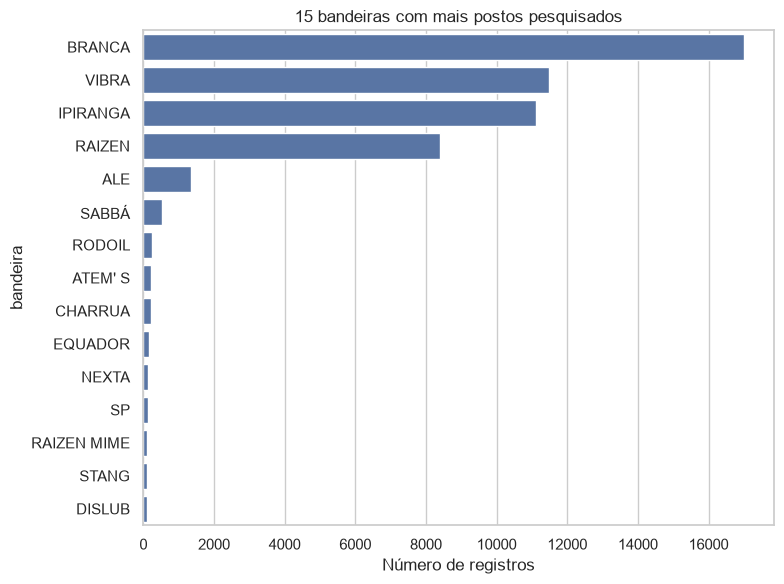

In [17]:
top_bandeiras = df['bandeira'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_bandeiras.values, y=top_bandeiras.index, ax=ax, orient='h')
ax.set_title('15 bandeiras com mais postos pesquisados')
ax.set_xlabel('Número de registros')
plt.tight_layout()
plt.show()

**Resultado:** a distribuição por bandeira é bem menos concentrada que por estado/produto — nenhuma bandeira domina o dataset. Por isso `bandeira` fica de fora das features numéricas por enquanto (só `produto` e `regiao` entram como categóricas no preprocessador), mas continua disponível nas tabelas de inspeção de anomalias.

## 8. Explorando possíveis anomalias (visual, sem treinar modelo)

Como referência — e só como EDA, sem ajustar nenhum modelo de sklearn — vemos quantos registros ficam a mais de 3 desvios-padrão da média de preço do seu próprio grupo (estado + produto). Isso dá uma noção de escala: quantos casos 'obviamente estranhos' já aparecem só com estatística descritiva, antes de qualquer IsolationForest/LOF/OneClassSVM.

Esse primeiro critério (z-score clássico) é só o ponto de partida — logo abaixo comparamos com dois métodos mais robustos (z-score modificado com mediana/MAD e cercas de Tukey) para checar se a contagem de "casos estranhos" se sustenta independente do método escolhido.

In [18]:
grupo = df.groupby(['estado', 'produto'])['valor_venda']
media_grupo = grupo.transform('mean')
desvio_grupo = grupo.transform('std')
z_score = (df['valor_venda'] - media_grupo) / desvio_grupo

candidatos_outlier = df[z_score.abs() > 3]
print('Registros com |z-score| > 3 dentro do grupo estado+produto:', len(candidatos_outlier))
print(f'Isso é {len(candidatos_outlier) / len(df):.2%} do total — poucos, como esperado.')
candidatos_outlier[['estado', 'municipio', 'revenda', 'produto', 'valor_venda', 'bandeira']].sort_values('valor_venda', ascending=False).head(10)

Registros com |z-score| > 3 dentro do grupo estado+produto: 396
Isso é 0.76% do total — poucos, como esperado.


,estado,municipio,revenda,produto,valor_venda,bandeira
46391,SP,BARUERI,AUTO POSTO DUQUE CONDE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.59,VIBRA
34972,SP,BARUERI,FGN COMERCIAL LTDA,GASOLINA ADITIVADA,9.49,VIBRA
34987,SP,BARUERI,CENTRO AUTOMOTIVO ALPHA CENTER LTDA,GASOLINA ADITIVADA,9.49,VIBRA
3761,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
24986,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
46867,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
36192,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
14238,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA ADITIVADA,9.49,VIBRA
13118,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.29,VIBRA
13117,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA,9.29,VIBRA


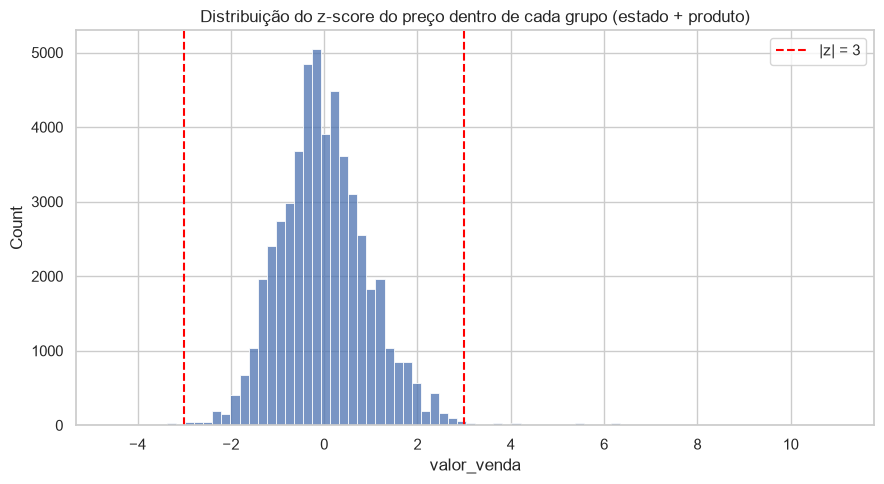

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(z_score.dropna(), bins=80, ax=ax)
ax.axvline(3, color='red', ls='--', label='|z| = 3')
ax.axvline(-3, color='red', ls='--')
ax.set_title('Distribuição do z-score do preço dentro de cada grupo (estado + produto)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/eda_zscore_preco_grupo.png', dpi=120)
plt.show()

**Resultado:** apenas 396 registros (0,76% do total) passam de 3 desvios-padrão do seu grupo — confirma numericamente que anomalias são raras neste dataset, na faixa de 1% ou menos, coerente com o `contamination` inicial de 2% usado como baseline no notebook 02. O histograma do z-score mostra uma distribuição concentrada perto de zero com caudas curtas, exatamente o padrão esperado quando poucos pontos são verdadeiramente anômalos.

### 8.1 O problema do z-score clássico: efeito de mascaramento (masking)

O z-score acima usa **média e desvio-padrão** do próprio grupo — mas média e desvio-padrão não são robustos: um único valor extremo já distorce os dois. Isso cria um problema conhecido em estatística robusta chamado **efeito de mascaramento**: quanto mais extremo (ou mais numeroso) for um outlier, mais ele infla o desvio-padrão do grupo, o que aumenta o denominador do z-score e "esconde" tanto a si mesmo quanto outros pontos moderadamente anômalos — na prática, o método usado para detectar outliers é contaminado pelos próprios outliers que deveria detectar. Formalmente, média e desvio-padrão têm **ponto de ruptura (breakdown point) de 0%**: basta uma observação arbitrariamente extrema para levar a estimativa a qualquer valor.

A alternativa clássica é o **z-score modificado de Iglewicz & Hoaglin**, que troca média/desvio-padrão por **mediana/MAD** (median absolute deviation), com ponto de ruptura de 50% — ou seja, até quase metade dos dados de um grupo pode ser extrema sem distorcer a referência:

$$z_{modificado} = 0{,}6745 \times \frac{x - \text{mediana}}{\text{MAD}}$$

A constante 0,6745 torna o MAD comparável ao desvio-padrão sob normalidade, e o limiar recomendado (NIST/Iglewicz & Hoaglin) é |z_modificado| > 3,5 em vez de 3.

In [20]:
mediana_grupo = grupo.transform('median')
mad_grupo = grupo.transform(lambda x: stats.median_abs_deviation(x, scale=1.0))

z_modificado = 0.6745 * (df['valor_venda'] - mediana_grupo) / mad_grupo
flag_robusto = z_modificado.abs() > 3.5

print('Registros com |z-score modificado| > 3.5:', flag_robusto.sum(), f'({flag_robusto.mean():.2%} do total)')
print('Para comparacao, o z-score classico (secao anterior) marcou:', (z_score.abs() > 3).sum())

Registros com |z-score modificado| > 3.5: 945 (1.81% do total)
Para comparacao, o z-score classico (secao anterior) marcou: 396


**Resultado:** o método robusto marca **945 registros (1,81%)**, mais que o **dobro** dos 396 (0,76%) do z-score clássico — evidência direta do efeito de mascaramento discutido acima: 582 registros só aparecem como anômalos quando trocamos média/desvio-padrão por mediana/MAD, porque no método clássico esses mesmos outliers (e outros ainda mais extremos no grupo) inflavam o desvio-padrão o suficiente para se camuflar. Há também 33 registros marcados só pelo método clássico — casos de grupos pequenos ou pouco variáveis onde o denominador de qualquer um dos dois métodos fica sensível a ruído.

**Uma ressalva honesta sobre o método robusto:** em 4 combinações (estado, produto) o MAD do grupo é exatamente zero (mais da metade dos preços do grupo é idêntica à mediana — grupos homogêneos, entre 4 e 271 postos). Nesses grupos, qualquer preço diferente da mediana produz um z-score modificado infinito e é automaticamente marcado como anomalia — isso responde por 156 dos 945 registros robustos (~16,5%). Não "corrigimos" isso escondendo o caso: é uma limitação real e conhecida de estatísticas baseadas em MAD quando o próprio MAD colapsa a zero, e reforça por que os modelos multivariados dos próximos notebooks (que olham o preço junto de produto/região de forma contínua, não grupo a grupo) são mais robustos na prática do que qualquer regra univariada isolada.

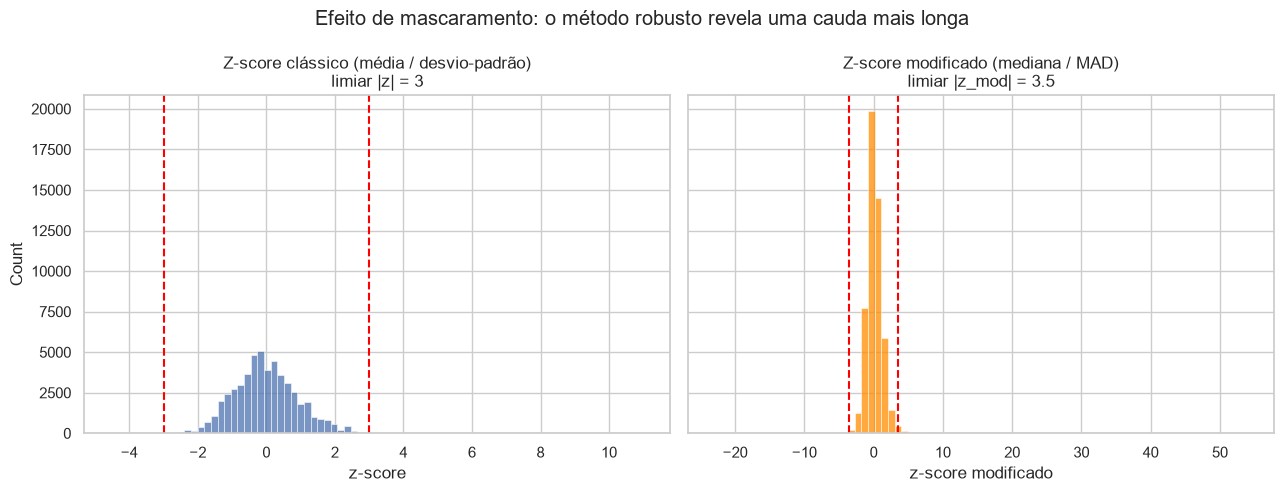

In [21]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sns.histplot(z_score.dropna(), bins=80, ax=eixos[0])
eixos[0].axvline(3, color='red', ls='--')
eixos[0].axvline(-3, color='red', ls='--')
eixos[0].set_title('Z-score clássico (média / desvio-padrão)\nlimiar |z| = 3')
eixos[0].set_xlabel('z-score')

sns.histplot(z_modificado.replace([np.inf, -np.inf], np.nan).dropna(), bins=80, ax=eixos[1], color='darkorange')
eixos[1].axvline(3.5, color='red', ls='--')
eixos[1].axvline(-3.5, color='red', ls='--')
eixos[1].set_title('Z-score modificado (mediana / MAD)\nlimiar |z_mod| = 3.5')
eixos[1].set_xlabel('z-score modificado')

fig.suptitle('Efeito de mascaramento: o método robusto revela uma cauda mais longa')
plt.tight_layout()
plt.savefig('../reports/eda_comparacao_zscore_classico_vs_robusto.png', dpi=120)
plt.show()

### 8.2 Uma terceira referência: as cercas de Tukey (IQR)

O método clássico de boxplot (Tukey, 1977) marca como outlier qualquer ponto fora de `[Q1 - 1,5×IQR, Q3 + 1,5×IQR]`, onde IQR = Q3 - Q1. Assim como o método robusto, usa estatísticas de ordem (quartis) em vez de média/desvio-padrão — mas com um ponto de ruptura menor (25%, não 50%) e uma limitação própria: em distribuições assimétricas (e já vimos que os 3 produtos têm assimetria positiva de 0,70 a 1,19), a cerca superior fica "apertada" demais em relação à cauda direita real, tendendo a marcar como outlier uma fatia maior da cauda longa do que faria sentido — preços legitimamente altos, não só erros.

In [22]:
q1 = grupo.transform(lambda x: x.quantile(0.25))
q3 = grupo.transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

flag_tukey = (df['valor_venda'] < limite_inferior) | (df['valor_venda'] > limite_superior)
print('Registros fora das cercas de Tukey:', flag_tukey.sum(), f'({flag_tukey.mean():.2%} do total)')

Registros fora das cercas de Tukey: 1532 (2.93% do total)


In [23]:
flag_classico = z_score.abs() > 3

resumo_metodos = pd.DataFrame({
    'metodo': ['Clássico (média/desvio, |z|>3)', 'Robusto (mediana/MAD, |z_mod|>3.5)', 'Tukey IQR (1.5x)'],
    'n_marcados': [flag_classico.sum(), flag_robusto.sum(), flag_tukey.sum()],
    'pct_marcados': [flag_classico.mean(), flag_robusto.mean(), flag_tukey.mean()],
})
print(resumo_metodos.to_string(index=False))

print('\nConcordância entre os 3 métodos:')
print('  Marcados pelos 3 ao mesmo tempo :', (flag_classico & flag_robusto & flag_tukey).sum())
print('  Marcados por pelo menos 1        :', (flag_classico | flag_robusto | flag_tukey).sum())
print('  Só pelo robusto (nem clássico, nem Tukey):', (flag_robusto & ~flag_classico & ~flag_tukey).sum())

                            metodo  n_marcados  pct_marcados
    Clássico (média/desvio, |z|>3)         396      0.007566
Robusto (mediana/MAD, |z_mod|>3.5)         945      0.018056
                  Tukey IQR (1.5x)        1532      0.029272

Concordância entre os 3 métodos:
  Marcados pelos 3 ao mesmo tempo : 361
  Marcados por pelo menos 1        : 1568
  Só pelo robusto (nem clássico, nem Tukey): 33


**Resultado:** os três métodos discordam bastante em volume — clássico 396 (0,76%), robusto 945 (1,81%), Tukey 1.532 (2,93%) — mas concordam em 361 registros marcados **simultaneamente pelos três**, um núcleo de casos que qualquer critério razoável classificaria como anômalo. A união dos três chega a 1.568 registros (3,0% do total); só 33 aparecem exclusivamente no robusto (nem no clássico, nem no Tukey) — a maior parte do que o robusto encontra a mais também é capturada pelo Tukey, o que dá confiança de que não é um artefato isolado do MAD.

**Síntese estatística desta seção:** nenhum método univariado sozinho é "o certo" — cada um assume algo diferente (normalidade implícita no z-score clássico; robustez a custo de um limiar de corte um pouco arbitrário no robusto; simetria aproximada no Tukey, que sabemos ser violada aqui). Por isso este notebook usa os três só como **triangulação exploratória** — para dimensionar a escala do problema (algo entre 0,8% e 3% dos registros, dependendo do critério) e verificar que a conclusão "anomalias são raras" é robusta ao método escolhido. A detecção de verdade fica a cargo dos modelos multivariados dos notebooks 02-04 (IsolationForest, LOF, OneClassSVM, EllipticEnvelope), que não dependem de um único limiar univariado nem assumem normalidade.

## 9. Conclusões da EDA

- O dataset tem 52.336 registros, sem nulos e sem duplicadas, com uma única coluna numérica relevante (`valor_venda`) e fortes efeitos de grupo por `estado` e `produto`.
- **`valor_venda` não é normal em nenhum dos 3 produtos** (teste de D'Agostino-Pearson, p≈0 nos três) e tem assimetria positiva (0,70 a 1,19) — gasolina e gasolina aditivada são ainda fortemente leptocúrticas (curtose em excesso 5,3-5,7). Isso descarta métodos que assumem normalidade e justifica estatisticamente as escolhas robustas/não-paramétricas usadas no restante do projeto (mediana em vez de média, Kruskal-Wallis em vez de ANOVA).
- **O efeito de região/estado sobre o preço é estatisticamente significativo e de tamanho prático relevante**, não só visual: Kruskal-Wallis rejeita H0 em todos os produtos (p≈0), com tamanho de efeito ε² entre 0,10 e 0,49 — e granularidade por **estado** explica bem mais variação do que por **região**, dando suporte estatístico direto à escolha de `estado + produto` como grupo de referência em `ReferenciaPrecos` (notebook 02). Preço bruto sozinho **não** é uma boa feature de anomalia: R$ 6,50 é comum no Acre (mediana de gasolina R$ 7,39) e seria um outlier forte no Piauí (mediana R$ 5,79).
- **A contagem de anomalias depende do método, mas a ordem de grandeza não**: z-score clássico (média/desvio) marca 396 registros (0,76%), mas sofre de efeito de mascaramento — o próprio desvio-padrão é inflado pelos outliers que deveria detectar. O z-score modificado (mediana/MAD, robusto a outliers) marca mais que o dobro, 945 (1,81%); as cercas de Tukey marcam 1.532 (2,93%). Os três concordam num núcleo de 361 registros. Confirma que anomalias são raras (entre ~1% e ~3% do total, dependendo do critério) e que nenhum método univariado isolado deve ser tomado como definitivo.
- Não há rótulo de fraude/erro: a avaliação de precision/recall dos modelos vai precisar de anomalias sintéticas injetadas (feito no notebook `04_avaliacao_tuning`).

**Próximo passo:** `02_preprocessing_baseline.ipynb` — split treino/teste, engenharia de features (desvio vs. mediana do grupo, ajustado somente no treino) e um modelo baseline de IsolationForest.